# Handwritten digits classification using CNN

# What is Handwritten Digit Recognition?
The handwritten digit recognition is the ability of computers to recognize human handwritten digits. It is a hard task for the machine because handwritten digits are not perfect and can be made with many different flavors. The handwritten digit recognition is the solution to this problem which uses the image of a digit and recognizes the digit present in the image.

# The MNIST dataset
This is probably one of the most popular datasets among machine learning and deep learning enthusiasts. The MNIST dataset contains 60,000 training images of handwritten digits from zero to nine and 10,000 images for testing. So, the MNIST dataset has 10 different classes. The handwritten digits images are represented as a 28×28 matrix where each cell contains grayscale pixel value.

# Import the libraries and load the dataset
First, we are going to import all the modules that we are going to need for training our model. The Keras library already contains some datasets and MNIST is one of them. So we can easily import the dataset and start working with it. The mnist.load_data() method returns us the training data, its labels and also the testing data and its labels.

# Preprocess the data
The image data cannot be fed directly into the model, so we need to perform some operations and process the data to make it ready for our neural network. We need to scale the pixel values (between 0 and 1) to help the model converge faster. The dimension of the training data is (60000, 28, 28). Since a CNN model requires a channel dimension to extract spatial features through convolutional layers, we reshape the matrix to (60000, 28, 28, 1).

In [ ]:
#pip install tensorflow

In [ ]:
# Importing TensorFlow and Keras to access deep learning tools and datasets

import tensorflow as tf
from tensorflow import keras

In [ ]:
# Loading the MNIST dataset (handwritten digits)
# It returns two tuples: one for training and one for testing

(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
# Displaying the raw pixel data of the training set

X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
# Displaying the raw pixel data of the test set

X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
X_test.shape

(10000, 28, 28)

In [ ]:
# Scaling the pixel values to a range of 0 to 1 (Normalization)
# This helps the model to converge faster and improves performance

X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Reshaping the training data to add a single channel (grayscale) for the CNN

X_train = X_train.reshape(-1, 28, 28, 1)

X_train.shape

(60000, 28, 28, 1)

In [ ]:
# Reshaping the test data to add a single channel (grayscale) for the CNN

X_test = X_test.reshape(-1, 28, 28, 1)

X_test.shape

(10000, 28, 28, 1)

In [ ]:
# Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,         # Randomly rotate images
    width_shift_range=0.1,     # Randomly translate images horizontally
    height_shift_range=0.1,    # Randomly translate images vertically
    zoom_range=0.1             # Randomly zoom images
)

datagen.fit(X_train)

In [ ]:
# Initializing the CNN structure with the first layer setup

cnn = tf.keras.models.Sequential()


# Input Layer Configuration (Keras 3 Standard)

cnn.add(tf.keras.Input(shape = [28, 28, 1]))


# Adding a 2D Convolutional layer to extract features from the 28x28 grayscale images

cnn.add(tf.keras.layers.Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'))


# Adding a Max Pooling layer to reduce spatial dimensions and prevent overfitting

cnn.add(tf.keras.layers.MaxPool2D(pool_size = (2,2), strides = 2))

In [ ]:
# Adding a Second Convolution Layer

cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size= (3,3), activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size= (2,2), strides=2))

In [ ]:
# Flattening the multi-dimensional pooled feature maps into a 1D vector

cnn.add(tf.keras.layers.Flatten())

In [ ]:
# Adding a fully connected (Dense) layer with 128 neurons for feature classification

cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [ ]:
# Applying a dropout rate of 20% to prevent overfitting during training

cnn.add(tf.keras.layers.Dropout(0.5))

In [ ]:
# Adding the final output layer with 10 units for multi-class classification

cnn.add(tf.keras.layers.Dense(units=10, activation='softmax'))

In [ ]:
# Compiling the CNN

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
# Setup Early Stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True)

In [ ]:
# Training the CNN and saving logs in 'training_progress'

print("Training Starts ... ... ... ")


batch_size = 64

training_progress = cnn.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Training Starts ... ... ... 
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 71ms/step - accuracy: 0.8539 - loss: 0.4614 - val_accuracy: 0.9799 - val_loss: 0.0579
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9442 - loss: 0.1851 - val_accuracy: 0.9889 - val_loss: 0.0306
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9585 - loss: 0.1423 - val_accuracy: 0.9890 - val_loss: 0.0305
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9659 - loss: 0.1187 - val_accuracy: 0.9926 - val_loss: 0.0221
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9694 - loss: 0.1014 - val_accuracy: 0.9919 - val_loss: 0.0246
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 69ms/step - accuracy: 0.9733 - loss: 0.0928 - val_accuracy: 0.9929 - val_loss: 0.0203
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.9758 - loss: 0.0817 - val_accuracy: 0.9909 - val_loss: 0.0290
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accur

In [ ]:
# Evaluating the model on test data

test_loss , test_accuracy = cnn.evaluate(X_test, y_test)

print(f" \n Test Accuracy : {test_accuracy*100:.2f}% ")
print(f" \n Test Loss : {test_loss:.2f} ")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9930 - loss: 0.0202
 
 Test Accuracy : 99.30% 
 
 Test Loss : 0.02 


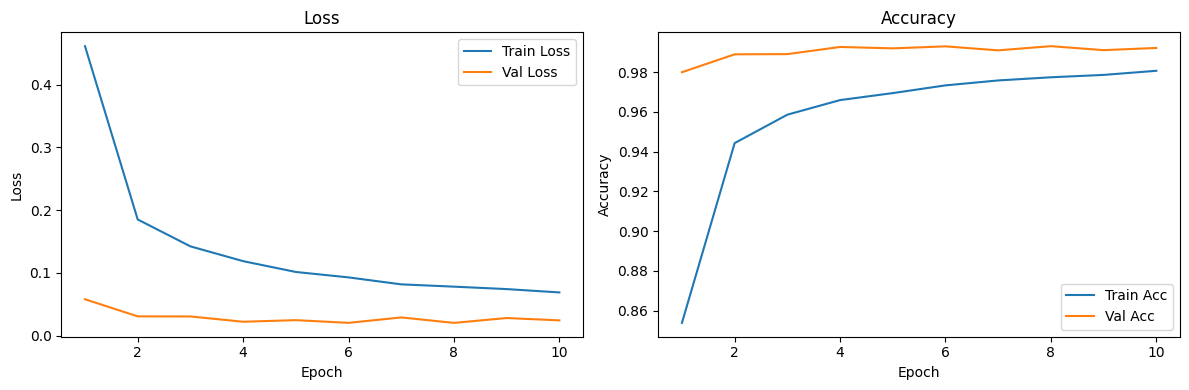

In [ ]:
import matplotlib.pyplot as plt

loss = training_progress.history['loss']
val_loss = training_progress.history['val_loss']
acc = training_progress.history['accuracy']
val_acc = training_progress.history['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Saving the entire CNN model (Architecture + Weights + Optimizer state)

cnn.save('CNN_Model_Digits_Recognition.keras')